In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

from scipy.stats import randint, uniform

import cv2
from skimage.feature import hog, local_binary_pattern

In [3]:
train1 = pd.read_csv("data_divided/training_cleaned.csv")
val = pd.read_csv("data_divided/validation_cleaned.csv")
train = pd.concat([train1, val], ignore_index = True)

test = pd.read_csv("data_divided/test_cleaned.csv")

print(f"The shape of train set: {train.shape}")
print(f"The shape of test set: {test.shape}")

The shape of train set: (15323, 12)
The shape of test set: (3809, 12)


In [5]:
train.head()

,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,3522.0,26.0,19.7,Unique,unknown,gallery,other,signed,75.0,6.0,other,images_thesis\2229548_1_m.jpg
1,2483.0,17.9,20.9,Unique,unknown,gallery,oil,signed,4.0,10.0,other,images_thesis\1594191_1_m.jpg
2,2798.0,27.6,51.2,Unique,female,independent,acrylic,signed,3.0,3.0,other,images_thesis\1554705_1_m.jpg
3,727.0,6.3,9.8,Unique,male,gallery,other,signed,42.0,10.0,France,images_thesis\291367_1_m.jpg
4,1500.0,24.0,24.0,Unique,female,gallery,oil,signed,1.0,1.0,United States,images_thesis\2323200_1_m.jpg


In [7]:
test.head()

,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,3270.0,41.3,36.6,Unique,female,independent,acrylic,signed,2.0,3.0,France,images_thesis\2162988_1_m.jpg
1,3209.0,45.7,35.0,Unique,male,independent,other,signed,9.0,6.0,France,images_thesis\1785561_1_m.jpg
2,315.0,12.0,10.7,Unique,male,independent,other,signed,0.0,4.0,other,images_thesis\2313675_1_m.jpg
3,729.0,23.8,17.9,Unique,female,gallery,other,signed,11.0,2.0,France,images_thesis\1901280_1_m.jpg
4,1002.0,31.5,15.7,Unique,unknown,gallery,acrylic,signed,1.0,2.0,France,images_thesis\2252911_1_m.jpg


In [9]:
# remowe image_path for models on tabular data

train_tab = train.drop(columns = "image_path")
test_tab = test.drop(columns = "image_path")

In [11]:
X_train, y_train = train_tab[train_tab.drop(columns = "price_numeric").columns.to_list()], train_tab["price_numeric"]
X_test, y_test = test_tab[test_tab.drop(columns = "price_numeric").columns.to_list()], test_tab["price_numeric"]

In [13]:
X_train.head()

,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location
0,26.0,19.7,Unique,unknown,gallery,other,signed,75.0,6.0,other
1,17.9,20.9,Unique,unknown,gallery,oil,signed,4.0,10.0,other
2,27.6,51.2,Unique,female,independent,acrylic,signed,3.0,3.0,other
3,6.3,9.8,Unique,male,gallery,other,signed,42.0,10.0,France
4,24.0,24.0,Unique,female,gallery,oil,signed,1.0,1.0,United States


In [51]:
X_test.head()


,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location
0,41.3,36.6,Unique,female,independent,acrylic,signed,2.0,3.0,France
1,45.7,35.0,Unique,male,independent,other,signed,9.0,6.0,France
2,12.0,10.7,Unique,male,independent,other,signed,0.0,4.0,other
3,23.8,17.9,Unique,female,gallery,other,signed,11.0,2.0,France
4,31.5,15.7,Unique,unknown,gallery,acrylic,signed,1.0,2.0,France


In [9]:

# detect column types
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# parameter distributions for randomized search
param_distributions = {
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": randint(2, 30),
    "model__min_samples_leaf": randint(1, 20),
    "model__max_leaf_nodes": [None, 10, 20, 50, 100],
    "model__ccp_alpha": uniform(0.0, 0.05)
}

# 5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
random_search.fit(X_train, y_train)

# store best parameters
best_params = random_search.best_params_

# best trained pipeline (already refit on full training data)
best_model = random_search.best_estimator_

print("Best parameters:", best_params)
print("Best CV MAE:", -random_search.best_score_)

C:\Users\yana1\AppData\Local\Temp\ipykernel_12364\2172734889.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


Best parameters: {'model__ccp_alpha': np.float64(0.026788734203737924), 'model__max_depth': None, 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 6, 'model__min_samples_split': 17}
Best CV MAE: 730.8514919088793


In [10]:
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)


In [11]:
def give_metrics(train_true, train_pred, test_true, test_pred):
    
    # train metrics
    mae_train = mean_absolute_error(train_true, train_pred)
    mse_train = mean_squared_error(train_true, train_pred)
    rmse_train = np.sqrt(mse_train)
    train_mean_y = np.mean(train_true)
    rmse_ratio_train = rmse_train / train_mean_y
    mae_ratio_train = mae_train / train_mean_y
    
    print("Metrics for the train")
    print("MAE:", mae_train)
    print("MSE:", mse_train)
    print("RMSE:", rmse_train)
    print("Normalized:", rmse_ratio_train)
    print("Normalized MAE:", mae_ratio_train)

    # test metrics
    mae_test = mean_absolute_error(test_true, test_pred)
    mse_test = mean_squared_error(test_true, test_pred)
    rmse_test = np.sqrt(mse_test)
    test_mean_y = np.mean(test_true)
    rmse_ratio_test = rmse_test / test_mean_y
    mae_ratio_test = mae_test / test_mean_y
    
    print("\nMetrics for the test")
    print("MAE:", mae_test)
    print("MSE:", mse_test)
    print("RMSE:", rmse_test)
    print("Normalized RMSE:", rmse_ratio_test)
    print("Normalized MAE:", mae_ratio_test)

In [12]:
give_metrics(y_train, y_pred_train, y_test, y_pred_test)


Metrics for the train
MAE: 533.1665767676142
MSE: 638426.6898479366
RMSE: 799.0160760885457
Normalized: 0.4337771090744988
Normalized MAE: 0.28945031676655897

Metrics for the test
MAE: 703.0385656671666
MSE: 1090242.3081825466
RMSE: 1044.1466890157467
Normalized RMSE: 0.5612598627261434
Normalized MAE: 0.3779041134818825


In [13]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_test)

0.41477362126633777

In [14]:


# pipeline for Random Forest
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# parameter distributions for randomized search
rf_param_distributions = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": randint(2, 30),
    "model__min_samples_leaf": randint(1, 20),
    "model__max_features": ["sqrt", "log2", None]
}

# 5-fold CV
rf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=50,
    cv=rf_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
rf_random_search.fit(X_train, y_train)

# store best parameters
rf_best_params = rf_random_search.best_params_

# best trained pipeline (already refit on full training data)
rf_best_model = rf_random_search.best_estimator_

print("RF Best parameters:", rf_best_params)
print("RF Best CV MAE:", -rf_random_search.best_score_)

RF Best parameters: {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 476}
RF Best CV MAE: 609.9268099531022


In [15]:
y_test_rf = rf_best_model.predict(X_test)
y_train_rf = rf_best_model.predict(X_train)

In [16]:
give_metrics(y_train, y_train_rf, y_test, y_test_rf)

Metrics for the train
MAE: 244.77815432659492
MSE: 146557.03987589016
RMSE: 382.82768953654613
Normalized: 0.20783297534357748
Normalized MAE: 0.13288738903498015

Metrics for the test
MAE: 582.3960690272744
MSE: 811017.214583241
RMSE: 900.5649419021602
Normalized RMSE: 0.48408040841889893
Normalized MAE: 0.3130551877367146


In [17]:
from xgboost import XGBRegressor

# pipeline for XGBoost
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

# parameter distributions
xgb_param_distributions = {
    "model__n_estimators": randint(100, 600),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0, 5)
}

# 5-fold CV
xgb_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=50,
    cv=xgb_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
xgb_random_search.fit(X_train, y_train)

# store best parameters
xgb_best_params = xgb_random_search.best_params_

# best trained pipeline (already refit on full training data)
xgb_best_model = xgb_random_search.best_estimator_

print("XGB Best parameters:", xgb_best_params)
print("XGB Best CV MAE:", -xgb_random_search.best_score_)

XGB Best parameters: {'model__colsample_bytree': np.float64(0.7123738038749523), 'model__gamma': np.float64(2.7134804157912424), 'model__learning_rate': np.float64(0.052277267492428794), 'model__max_depth': 9, 'model__min_child_weight': 1, 'model__n_estimators': 444, 'model__subsample': np.float64(0.9947547746402069)}
XGB Best CV MAE: 607.5833197599989


In [18]:
train_xg = xgb_best_model.predict(X_train)
test_xg = xgb_best_model.predict(X_test)

In [19]:
give_metrics(y_train, train_xg, y_test, test_xg)

Metrics for the train
MAE: 324.42495913253646
MSE: 257348.56950482933
RMSE: 507.2953474109824
Normalized: 0.275405108648269
Normalized MAE: 0.17612677028106355

Metrics for the test
MAE: 589.6279055541443
MSE: 806425.0141291863
RMSE: 898.0117004411392
Normalized RMSE: 0.48270796528711046
Normalized MAE: 0.31694251469855655


In [20]:
import shap
import numpy as np
import pandas as pd

import shap
import numpy as np
import pandas as pd

def compute_shap_from_best_model(
    best_model,
    X_train,
    X_test,
    background_size=200,
    random_state=None,
):
    # --- extract pipeline parts ---
    preprocessor = best_model.named_steps["preprocessing"]
    model = best_model.named_steps["model"]

    # --- transform data ---
    X_train_trans = preprocessor.transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # --- feature names ---
    feature_names = preprocessor.get_feature_names_out()

    # --- convert to DataFrame ---
    X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)

    # --- reproducible RNG ---
    rng = np.random.default_rng(random_state)

    # --- background sample ---
    n_background = min(background_size, X_train_trans.shape[0])
    idx = rng.choice(X_train_trans.shape[0], size=n_background, replace=False)

    X_background = pd.DataFrame(X_train_trans[idx], columns=feature_names)

    # --- SHAP ---
    explainer = shap.Explainer(model, X_background)
    shap_values = explainer(X_test_df, check_additivity=False)

    # --- mean |SHAP| ---
    importance = np.abs(shap_values.values).mean(axis=0)

    return importance, feature_names


# --- compute for all 3 ---
imp_dt, features = compute_shap_from_best_model(best_model, X_train, X_test, random_state = 42)
imp_rf, _        = compute_shap_from_best_model(rf_best_model, X_train, X_test, random_state = 42)
imp_xgb, _       = compute_shap_from_best_model(xgb_best_model, X_train, X_test, random_state = 42)


# --- combine ---
df_imp = pd.DataFrame({
    "feature": features,
    "Decision Tree": imp_dt,
    "Random Forest": imp_rf,
    "XGBoost": imp_xgb
})

# --- sort by overall importance ---
df_imp["mean_all"] = df_imp[["Decision Tree", "Random Forest", "XGBoost"]].mean(axis=1)
df_imp = df_imp.sort_values("mean_all", ascending=False).drop(columns="mean_all")

df_imp.head()

100%|===================| 3793/3809 [02:08<00:00]        

,feature,Decision Tree,Random Forest,XGBoost
17,num__Height,389.088068,383.911611,371.141862
18,num__Width,361.725033,350.312671,364.415485
20,num__years_selling,178.624587,156.873389,191.750918
19,num__age,99.251453,99.808732,95.943294
8,cat__painting_oil,77.268568,84.729786,80.563550


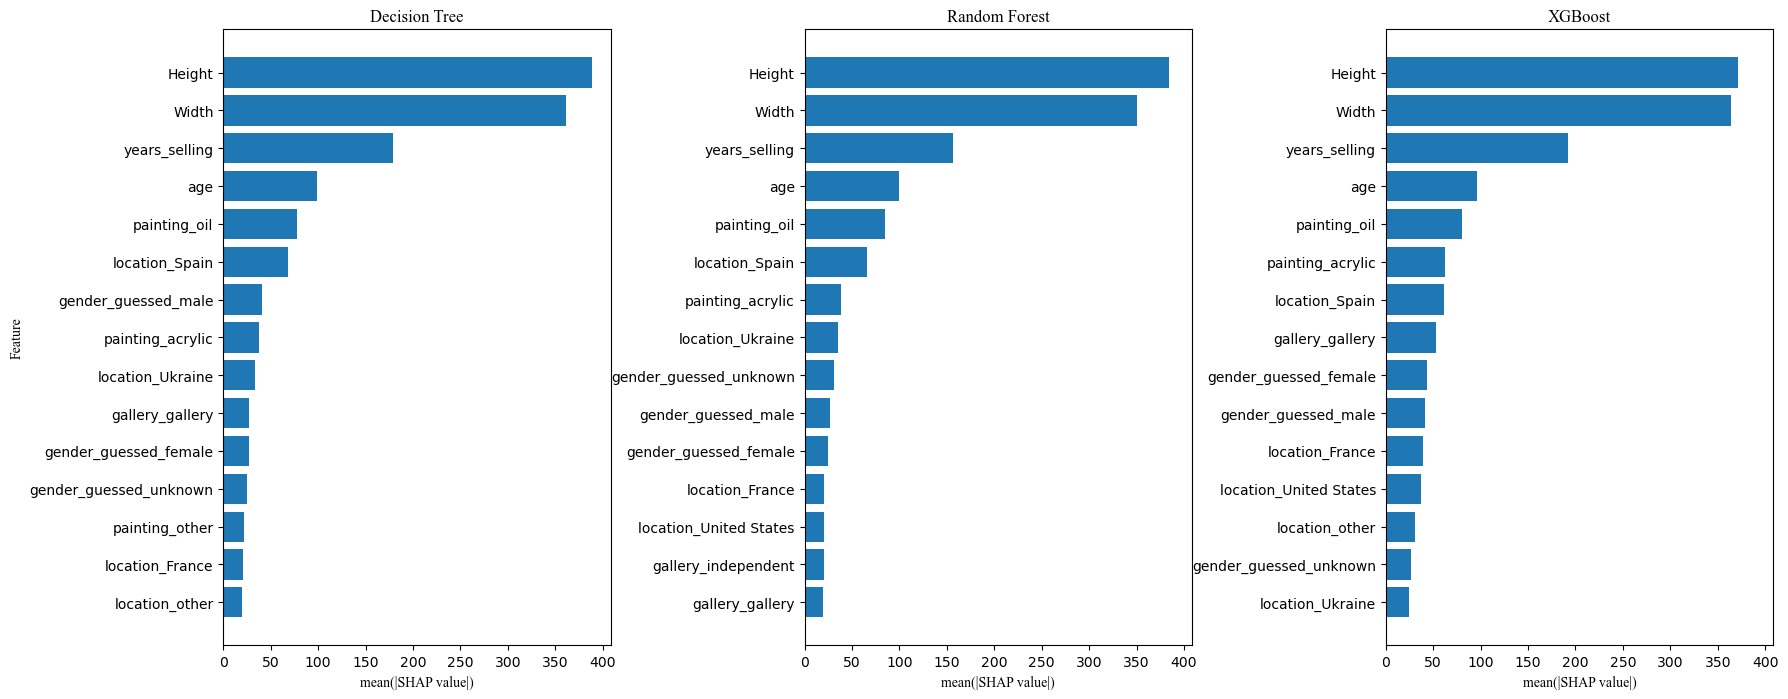

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# optional: cleaner labels
df_plot = df_imp.copy()
df_plot["feature_clean"] = (
    df_plot["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

# top features separately for each model
top_n = 15
dt_top = df_plot.nlargest(top_n, "Decision Tree").sort_values("Decision Tree", ascending=True)
rf_top = df_plot.nlargest(top_n, "Random Forest").sort_values("Random Forest", ascending=True)
xgb_top = df_plot.nlargest(top_n, "XGBoost").sort_values("XGBoost", ascending=True)

# common x-axis limit across all three top-15 subsets
x_max = max(
    dt_top["Decision Tree"].max(),
    rf_top["Random Forest"].max(),
    xgb_top["XGBoost"].max()
)
x_limit = x_max * 1.05

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Decision Tree
axes[0].barh(dt_top["feature_clean"], dt_top["Decision Tree"])
axes[0].set_title("Decision Tree", fontname="Times New Roman")
axes[0].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman")
axes[0].set_ylabel("Feature", fontname="Times New Roman")
axes[0].set_xlim(0, x_limit)

# Random Forest
axes[1].barh(rf_top["feature_clean"], rf_top["Random Forest"])
axes[1].set_title("Random Forest", fontname="Times New Roman")
axes[1].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman")
axes[1].set_xlim(0, x_limit)

# XGBoost
axes[2].barh(xgb_top["feature_clean"], xgb_top["XGBoost"])
axes[2].set_title("XGBoost", fontname="Times New Roman")
axes[2].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman")
axes[2].set_xlim(0, x_limit)

plt.subplots_adjust(wspace=0.5)

plt.savefig("shap_cl.png", dpi = 700)
plt.show()

In [15]:
# define the function to load and resize images

def load_and_resize(path, size=128):     # image size reccomended for handcrafted images
    img = cv2.imread(path)
    
    if img is None:
        raise ValueError(f"Image not found: {path}")
    
    img = cv2.resize(img, (size, size))
    
    return img

In [17]:
# load images, transform to np array, define array of prices

X_train_images = np.array([
    load_and_resize(p, 128)
    for p in train["image_path"]
])

X_test_images = np.array([
    load_and_resize(p, 128)
    for p in test["image_path"]
])


In [19]:
print(X_train_images.shape)
print(X_test_images.shape)
print(y_train.shape)
print(y_test.shape)

(15323, 128, 128, 3)
(3809, 128, 128, 3)
(15323,)
(3809,)


In [21]:
print(X_train_images.dtype)
print(X_test_images.dtype)

uint8
uint8


In [23]:


def extract_image_features(images):
    
    feature_list = []
    feature_names = None

    for image in images:

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        hog_feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm="L2-Hys",
            feature_vector=True
        )

        lbp = local_binary_pattern(gray, 8, 1, method="uniform")
        lbp_bins = 10

        lbp_hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, lbp_bins+1),
            range=(0, lbp_bins)
        )

        lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)

        rgb_hist = []
        for ch in range(3):
            hist = cv2.calcHist([image],[ch],None,[32],[0,256])
            hist = cv2.normalize(hist,hist).flatten()
            rgb_hist.extend(hist)

        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        hsv_hist = []
        ranges = [[0,180],[0,256],[0,256]]

        for ch in range(3):
            hist = cv2.calcHist([hsv],[ch],None,[32],ranges[ch])
            hist = cv2.normalize(hist,hist).flatten()
            hsv_hist.extend(hist)

        features = np.concatenate([
            hog_feat,
            lbp_hist,
            rgb_hist,
            hsv_hist
        ])

        feature_list.append(features)

        if feature_names is None:

            hog_names = [f"hog_{i}" for i in range(len(hog_feat))]
            lbp_names = [f"lbp_{i}" for i in range(len(lbp_hist))]
            rgb_names = [f"rgb_{i}" for i in range(len(rgb_hist))]
            hsv_names = [f"hsv_{i}" for i in range(len(hsv_hist))]

            feature_names = hog_names + lbp_names + rgb_names + hsv_names

    return pd.DataFrame(feature_list, columns=feature_names)

In [25]:
X_train_features = extract_image_features(X_train_images)
X_test_features = extract_image_features(X_test_images)

print(X_train_features.shape)
print(X_test_features.shape)

(15323, 8302)
(3809, 8302)


In [66]:
X_train_features.head()

,hog_0,hog_1,hog_2,hog_3,hog_4,hog_5,hog_6,hog_7,hog_8,hog_9,...,hsv_86,hsv_87,hsv_88,hsv_89,hsv_90,hsv_91,hsv_92,hsv_93,hsv_94,hsv_95
0,0.262779,0.105419,0.019519,0.023247,0.066783,0.097094,0.076797,0.099979,0.149782,0.262779,...,0.341637,0.408041,0.511113,0.381435,0.124313,0.008943,0.000224,0.000000,0.000000,0.000000
1,0.153948,0.026690,0.065952,0.097952,0.265924,0.237055,0.173293,0.011936,0.054559,0.260895,...,0.004957,0.002754,0.004039,0.007711,0.007894,0.005324,0.000734,0.000000,0.000000,0.000000
2,0.244569,0.244569,0.232250,0.117607,0.244569,0.031307,0.029216,0.154558,0.237512,0.244569,...,0.151949,0.153010,0.183781,0.198212,0.244051,0.369897,0.506778,0.506990,0.302836,0.158527
3,0.148339,0.043956,0.018255,0.010741,0.264399,0.007595,0.009472,0.000000,0.081887,0.303479,...,0.040292,0.039476,0.037519,0.050895,0.110762,0.609274,0.737491,0.074222,0.007504,0.000163
4,0.244828,0.054469,0.068898,0.213202,0.244828,0.197088,0.103347,0.054469,0.088733,0.244828,...,0.088953,0.127271,0.190375,0.435490,0.571428,0.566106,0.303201,0.078613,0.000000,0.000000


In [27]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(
    X_train_features,
    y_train,
    random_state=42
)

mi = pd.Series(mi, index=X_train_features.columns)
mi = mi.sort_values(ascending=False)

In [29]:
# 2. Choose how many features to keep
top_n = 100

selected_features = mi.index[:top_n]

# 3. Subset both train and test using TRAIN-derived feature names
X_train_selected = X_train_features.loc[:, selected_features]
X_test_selected = X_test_features.loc[:, selected_features]

In [31]:
X_test_selected.to_csv("test_features_cleaned_im.csv")
X_train_selected.to_csv("train_features_cleaned_im.csv")

In [31]:


model = DecisionTreeRegressor(random_state=42)

param_distributions = {
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 20),
    "max_leaf_nodes": [None, 10, 20, 50, 100],
    "ccp_alpha": uniform(0.0, 0.05)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_search_dt_im = RandomizedSearchCV(
    model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

random_search_dt_im.fit(X_train_selected, y_train)

best_model_dt_im = random_search_dt_im.best_estimator_

print("Best parameters:", random_search.best_params_)
print("Best CV MAE:", -random_search.best_score_)

Best parameters: {'model__ccp_alpha': np.float64(0.026788734203737924), 'model__max_depth': None, 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 6, 'model__min_samples_split': 17}
Best CV MAE: 730.8514919088793


In [32]:
y_pred_test_dtim = best_model_dt_im.predict(X_test_selected)
y_pred_train_dtim = best_model_dt_im.predict(X_train_selected)

In [33]:
give_metrics(y_train, y_pred_train_dtim, y_test, y_pred_test_dtim)

Metrics for the train
MAE: 1049.32804381512
MSE: 1743741.1676613041
RMSE: 1320.5079203326666
Normalized: 0.716889340945382
Normalized MAE: 0.5696687450209451

Metrics for the test
MAE: 1076.9533388665602
MSE: 1858843.7541901348
RMSE: 1363.3942035193397
Normalized RMSE: 0.7328648853258434
Normalized MAE: 0.5788944115739965


In [34]:


# define the model
rf_model = RandomForestRegressor(random_state=42)

# parameter distributions for randomized search
rf_param_distributions = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None]
}

# 5-fold CV
rf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
rf_random_search_im = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_param_distributions,
    n_iter=50,
    cv=rf_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
rf_random_search_im.fit(X_train_selected, y_train)

# store best parameters
rf_best_params_im = rf_random_search_im.best_params_

# best trained model (already refit on full training data)
rf_best_model_im = rf_random_search_im.best_estimator_

print("RF Best parameters:", rf_best_params)
print("RF Best CV MAE:", -rf_random_search.best_score_)

RF Best parameters: {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 476}
RF Best CV MAE: 609.9268099531022


In [35]:
y_pred_test_rfim = rf_best_model_im.predict(X_test_selected)
y_pred_train_rfim = rf_best_model_im.predict(X_train_selected)

give_metrics(y_train, y_pred_train_rfim, y_test, y_pred_test_rfim)

Metrics for the train
MAE: 785.6921471866696
MSE: 1007472.2256114613
RMSE: 1003.729159490478
Normalized: 0.5449136082830283
Normalized MAE: 0.42654369346055626

Metrics for the test
MAE: 1052.410365646527
MSE: 1790466.1142361106
RMSE: 1338.0829997560356
Normalized RMSE: 0.7192593614094511
Normalized MAE: 0.5657018343956384


In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

# define the model
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# parameter distributions for randomized search
xgb_param_distributions = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5)
}

# 5-fold CV
xgb_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
xgb_random_search_im = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_param_distributions,
    n_iter=50,
    cv=xgb_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
xgb_random_search_im.fit(X_train_selected, y_train)

# store best parameters
xgb_best_params_im = xgb_random_search_im.best_params_

# best trained model (already refit on full training data)
xgb_best_model_im = xgb_random_search_im.best_estimator_

print("XGB Best parameters:", xgb_best_params_im)
print("XGB Best CV MAE:", -xgb_random_search_im.best_score_)

XGB Best parameters: {'colsample_bytree': np.float64(0.9977829850443283), 'gamma': np.float64(0.8796262633867269), 'learning_rate': np.float64(0.015422609084656261), 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 403, 'subsample': np.float64(0.8985965620472096)}
XGB Best CV MAE: 1030.0738003750184


In [37]:
y_pred_test_xgim = xgb_best_model_im.predict(X_test_selected)
y_pred_train_xgim = xgb_best_model_im.predict(X_train_selected)

give_metrics(y_train, y_pred_train_xgim, y_test, y_pred_test_xgim)

Metrics for the train
MAE: 602.2348508176982
MSE: 580854.5072712101
RMSE: 762.1381156137056
Normalized: 0.4137564667344228
Normalized MAE: 0.32694672909517714

Metrics for the test
MAE: 1044.853039345675
MSE: 1777899.4276471324
RMSE: 1333.3789512539684
Normalized RMSE: 0.7167307956013115
Normalized MAE: 0.5616395470112947


In [38]:
import shap
import numpy as np
import pandas as pd

def compute_shap_from_plain_model(
    best_model,
    X_train,
    X_test,
    background_size=200,
    random_state=None,
):
    # --- ensure DataFrame (preserve feature names) ---
    X_train_df = X_train.copy() if isinstance(X_train, pd.DataFrame) else pd.DataFrame(X_train)
    X_test_df  = X_test.copy()  if isinstance(X_test, pd.DataFrame)  else pd.DataFrame(X_test)

    # --- reproducible random generator ---
    rng = np.random.default_rng(random_state)

    # --- background sample ---
    n_background = min(background_size, X_train_df.shape[0])
    idx = rng.choice(X_train_df.shape[0], size=n_background, replace=False)

    X_background = X_train_df.iloc[idx].copy()

    # --- SHAP ---
    explainer = shap.Explainer(best_model, X_background)
    shap_values = explainer(X_test_df, check_additivity=False)

    # --- mean absolute SHAP importance ---
    importance = np.abs(shap_values.values).mean(axis=0)

    return importance, X_test_df.columns


# compute for all 3
imp_dt_im, features_im = compute_shap_from_plain_model(
    best_model_dt_im, X_train_selected, X_test_selected, random_state = 42
)

imp_rf_im, _ = compute_shap_from_plain_model(
    rf_best_model_im, X_train_selected, X_test_selected, random_state = 42
)

imp_xgb_im, _ = compute_shap_from_plain_model(
    xgb_best_model_im, X_train_selected, X_test_selected, random_state = 42
)

# combine
df_imp_im = pd.DataFrame({
    "feature": features_im,
    "Decision Tree": imp_dt_im,
    "Random Forest": imp_rf_im,
    "XGBoost": imp_xgb_im
})

df_imp_im.head()

100%|===================| 3793/3809 [01:56<00:00]        

,feature,Decision Tree,Random Forest,XGBoost
0,rgb_62,70.822617,30.985965,23.371661
1,hog_125,0.000000,3.892901,6.457958
2,hog_7775,0.000000,7.481223,10.985789
3,rgb_60,0.000000,12.865448,33.133114
4,rgb_30,11.099844,21.199151,48.845475


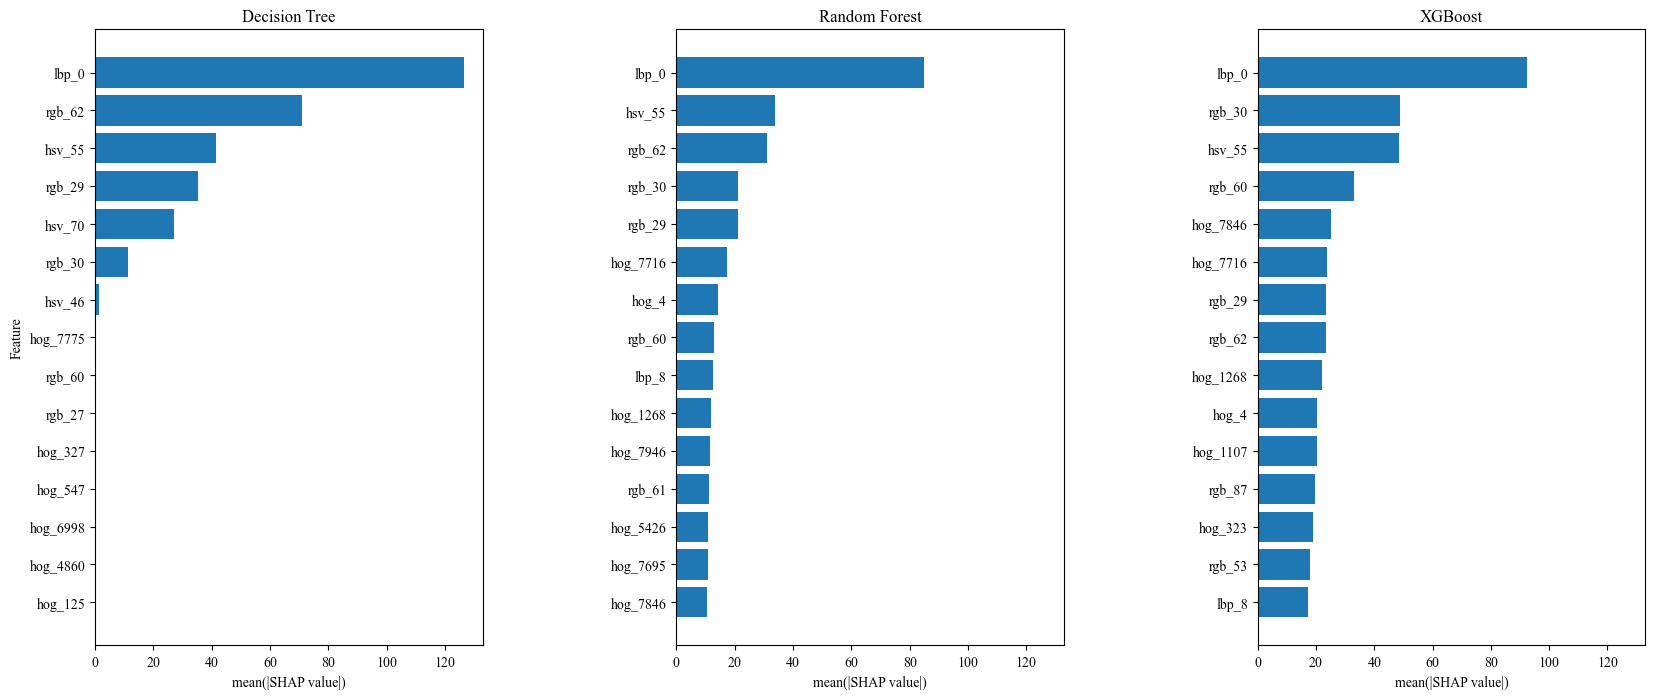

In [39]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

df_plot = df_imp_im.copy()

top_n = 15

# --- top features per model ---
dt_top = df_plot.nlargest(top_n, "Decision Tree").sort_values("Decision Tree", ascending=True)
rf_top = df_plot.nlargest(top_n, "Random Forest").sort_values("Random Forest", ascending=True)
xgb_top = df_plot.nlargest(top_n, "XGBoost").sort_values("XGBoost", ascending=True)

# --- shared x-axis limit ---
x_max = max(
    dt_top["Decision Tree"].max(),
    rf_top["Random Forest"].max(),
    xgb_top["XGBoost"].max()
)
x_limit = x_max * 1.05

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Decision Tree
axes[0].barh(dt_top["feature"], dt_top["Decision Tree"])
axes[0].set_title("Decision Tree")
axes[0].set_xlabel("mean(|SHAP value|)")
axes[0].set_ylabel("Feature")
axes[0].set_xlim(0, x_limit)

# Random Forest
axes[1].barh(rf_top["feature"], rf_top["Random Forest"])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("mean(|SHAP value|)")
axes[1].set_xlim(0, x_limit)

# XGBoost
axes[2].barh(xgb_top["feature"], xgb_top["XGBoost"])
axes[2].set_title("XGBoost")
axes[2].set_xlabel("mean(|SHAP value|)")
axes[2].set_xlim(0, x_limit)

plt.subplots_adjust(wspace=0.5)


plt.savefig("shap_im_cl.png", dpi = 700)

plt.show()

In [40]:
import joblib

# save
joblib.dump(best_model, "best_model_dt_cl.joblib")
joblib.dump(rf_best_model, "rf_best_model_cl.joblib")
joblib.dump(xgb_best_model, "xgb_best_model_cl.joblib")
joblib.dump(best_model_dt_im, "best_model_dt_im_cl.joblib")
joblib.dump(rf_best_model_im, "best_model_rf_im_cl.joblib")
joblib.dump(xgb_best_model_im, "best_model_xgb_im_cl.joblib")


['best_model_xgb_im_cl.joblib']

In [83]:
df_imp_im.to_csv("df_imp_im.csv")
df_imp.to_csv("df_imp.csv")

In [5]:
df_imp_im = pd.read_csv("df_imp_im.csv")
df_imp = pd.read_csv("df_imp.csv")

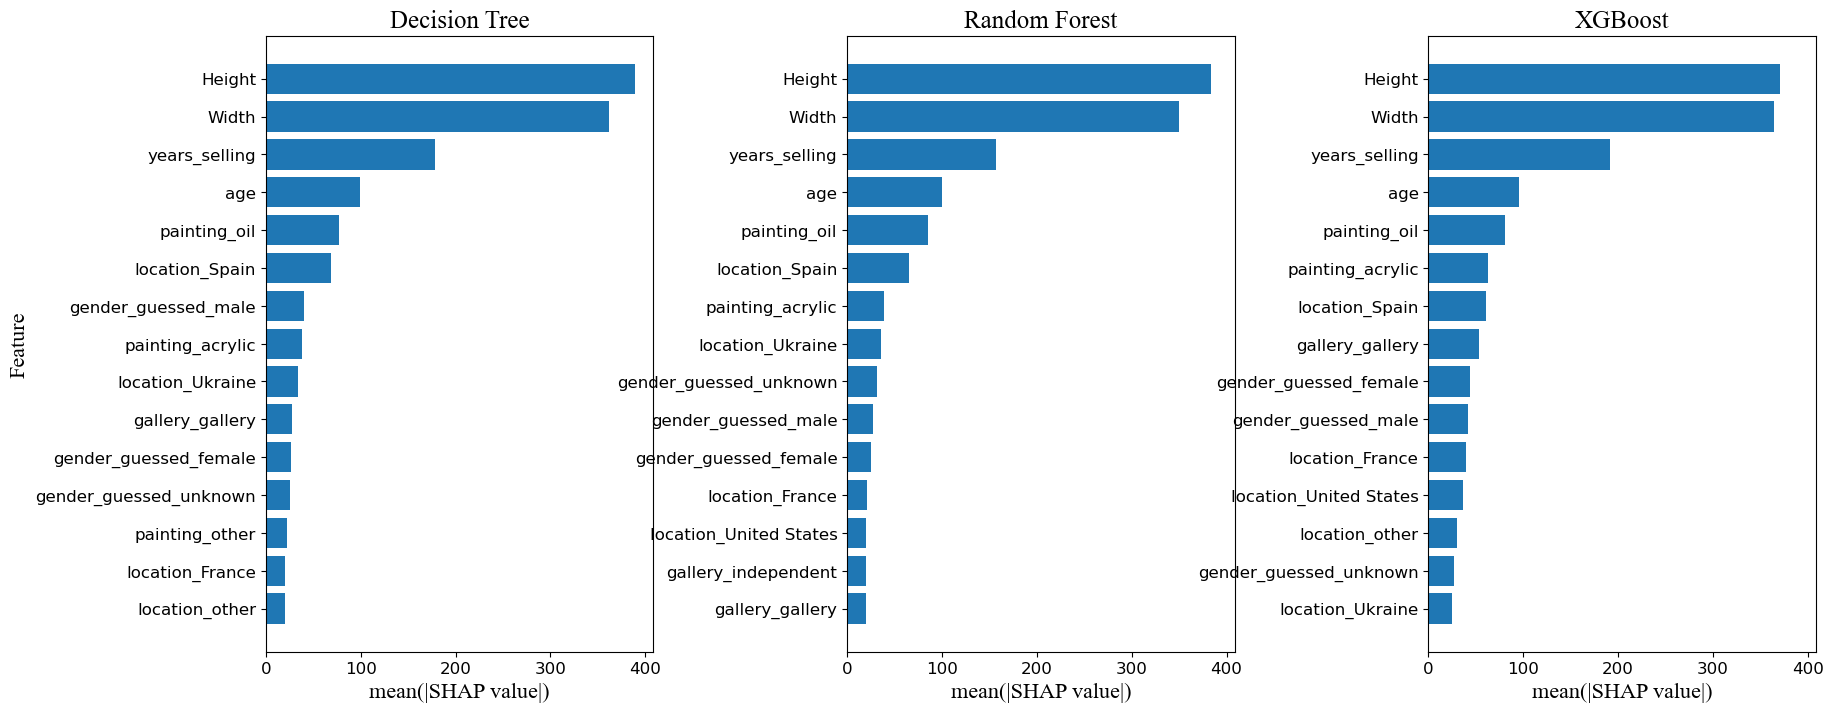

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# font size variables
title_fs = 18
label_fs = 16
tick_fs = 12


# optional: cleaner labels
df_plot = df_imp.copy()
df_plot["feature_clean"] = (
    df_plot["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

# top features separately for each model
top_n = 15
dt_top = df_plot.nlargest(top_n, "Decision Tree").sort_values("Decision Tree", ascending=True)
rf_top = df_plot.nlargest(top_n, "Random Forest").sort_values("Random Forest", ascending=True)
xgb_top = df_plot.nlargest(top_n, "XGBoost").sort_values("XGBoost", ascending=True)

# common x-axis limit across all three top-15 subsets
x_max = max(
    dt_top["Decision Tree"].max(),
    rf_top["Random Forest"].max(),
    xgb_top["XGBoost"].max()
)
x_limit = x_max * 1.05

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Decision Tree
axes[0].barh(dt_top["feature_clean"], dt_top["Decision Tree"])
axes[0].set_title("Decision Tree", fontname="Times New Roman", fontsize=title_fs)
axes[0].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman", fontsize=label_fs)
axes[0].set_ylabel("Feature", fontname="Times New Roman", fontsize=label_fs)
axes[0].set_xlim(0, x_limit)
axes[0].tick_params(axis='both', labelsize=tick_fs)

# Random Forest
axes[1].barh(rf_top["feature_clean"], rf_top["Random Forest"])
axes[1].set_title("Random Forest", fontname="Times New Roman", fontsize=title_fs)
axes[1].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman", fontsize=label_fs)
axes[1].set_xlim(0, x_limit)
axes[1].tick_params(axis='both', labelsize=tick_fs)

# XGBoost
axes[2].barh(xgb_top["feature_clean"], xgb_top["XGBoost"])
axes[2].set_title("XGBoost", fontname="Times New Roman", fontsize=title_fs)
axes[2].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman", fontsize=label_fs)
axes[2].set_xlim(0, x_limit)
axes[2].tick_params(axis='both', labelsize=tick_fs)

plt.subplots_adjust(wspace=0.5)

plt.savefig("shap_cl.png", dpi=700)
plt.show()